# Simulate Cost Notebook

Run the cells in order. This notebook stores the raw simulated data and the summary results for every scenario.

In [ ]:
import os
import random

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize_scalar

## Parameters And Storage

Paper notation used here:

- `alpha` = demand uncertainty
- `beta` = estimate uncertainty

This cell creates the main objects you can work with later:

- `scenario_data`: raw `D` and `E` for each scenario
- `summary_rows`: summary numbers before turning them into a table
- `scenario_table`: tidy table created later
- `total_cost_matrix`: 4x4 matrix for the heatmap
- `estimate_samples_matrix`: 4x4 stored `E` samples for the histograms

In [ ]:
# Parameters
ITERATIONS = 10000
SHORTFALL_COST = 2.0  # c^s

# In the paper notation:
# alpha = demand uncertainty
# beta = estimate uncertainty
UNCERTAINTY_LEVELS = {
    "none": 0.0,
    "low": 0.25,
    "med": 0.5,
    "high": 0.75,
}
SEED = 123

levels = list(UNCERTAINTY_LEVELS.keys())
total_cost_matrix = [[0.0 for _ in levels] for _ in levels]
estimate_samples_matrix = [[None for _ in levels] for _ in levels]

# Main storage objects
scenario_data = {}
summary_rows = []

os.makedirs("Figures", exist_ok=True)

## Run Simulation And Store Everything

This cell simulates `D` and `E`, optimizes `S`, and stores both the raw samples and the expected costs.

In the equations from the paper:

- `D ~ LogNormal(-alpha^2 / 2, alpha^2)`
- `E = D * LogNormal(-beta^2 / 2, beta^2)`

In [ ]:
header = (
    f"{'Demand':<6} {'Estimate':<8} "
    f"{'Exp inv cost':>14} {'Exp short cost':>16} {'Exp total cost':>16}"
)
print(header)
print("-" * len(header))

scenario_data.clear()
summary_rows.clear()
total_cost_matrix = [[0.0 for _ in levels] for _ in levels]
estimate_samples_matrix = [[None for _ in levels] for _ in levels]

for demand_label, demand_sigma in UNCERTAINTY_LEVELS.items():
    for estimate_label, estimate_sigma in UNCERTAINTY_LEVELS.items():
        rng = random.Random(f"{SEED}:{demand_label}:{estimate_label}")

        alpha = demand_sigma
        beta = estimate_sigma

        D = []
        E = []

        for _ in range(ITERATIONS):
            if alpha == 0:
                demand = 1.0
            else:
                demand_mu = -0.5 * alpha * alpha
                demand = rng.lognormvariate(demand_mu, alpha)

            if beta == 0:
                estimate_noise = 1.0
            else:
                estimate_mu = -0.5 * beta * beta
                estimate_noise = rng.lognormvariate(estimate_mu, beta)

            estimate = demand * estimate_noise

            D.append(demand)
            E.append(estimate)

        result = minimize_scalar(
            lambda S: S + SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS,
            bounds=(0.0, max(E)),
            method="bounded",
        )

        S = result.x
        expected_investment_cost = S
        expected_shortfall_cost = SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS
        expected_total_cost = expected_investment_cost + expected_shortfall_cost
        expected_demand_shortfall_cost = SHORTFALL_COST * sum(max(d - S, 0.0) for d in D) / ITERATIONS
        expected_demand_total_cost = expected_investment_cost + expected_demand_shortfall_cost

        row_index = levels.index(demand_label)
        col_index = levels.index(estimate_label)
        total_cost_matrix[row_index][col_index] = expected_total_cost
        estimate_samples_matrix[row_index][col_index] = E.copy()

        scenario_data[(demand_label, estimate_label)] = {
            "alpha": alpha,
            "beta": beta,
            "D": D.copy(),
            "E": E.copy(),
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        }

        summary_rows.append({
            "demand_level": demand_label,
            "estimate_level": estimate_label,
            "alpha": alpha,
            "beta": beta,
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        })

        print(
            f"{demand_label:<6} "
            f"{estimate_label:<8} "
            f"{expected_investment_cost:>14.4f} "
            f"{expected_shortfall_cost:>16.4f} "
            f"{expected_total_cost:>16.4f}"
        )

## Inspect Stored Data

These cells let you play with the stored results directly.

In [ ]:
scenario_table = pd.DataFrame(summary_rows)
scenario_table

In [ ]:
list(scenario_data.keys())

In [ ]:
scenario_data[("low", "high")]

In [ ]:
scenario_data[("low", "high")]["D"][:10], scenario_data[("low", "high")]["E"][:10]

## Plots

In [ ]:
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(total_cost_matrix, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Expected total cost by uncertainty scenario", fontsize=15, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        value = total_cost_matrix[row_index][col_index]
        ax.text(col_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=11, color="black")

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label("Expected total cost", fontsize=12, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_total_cost_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

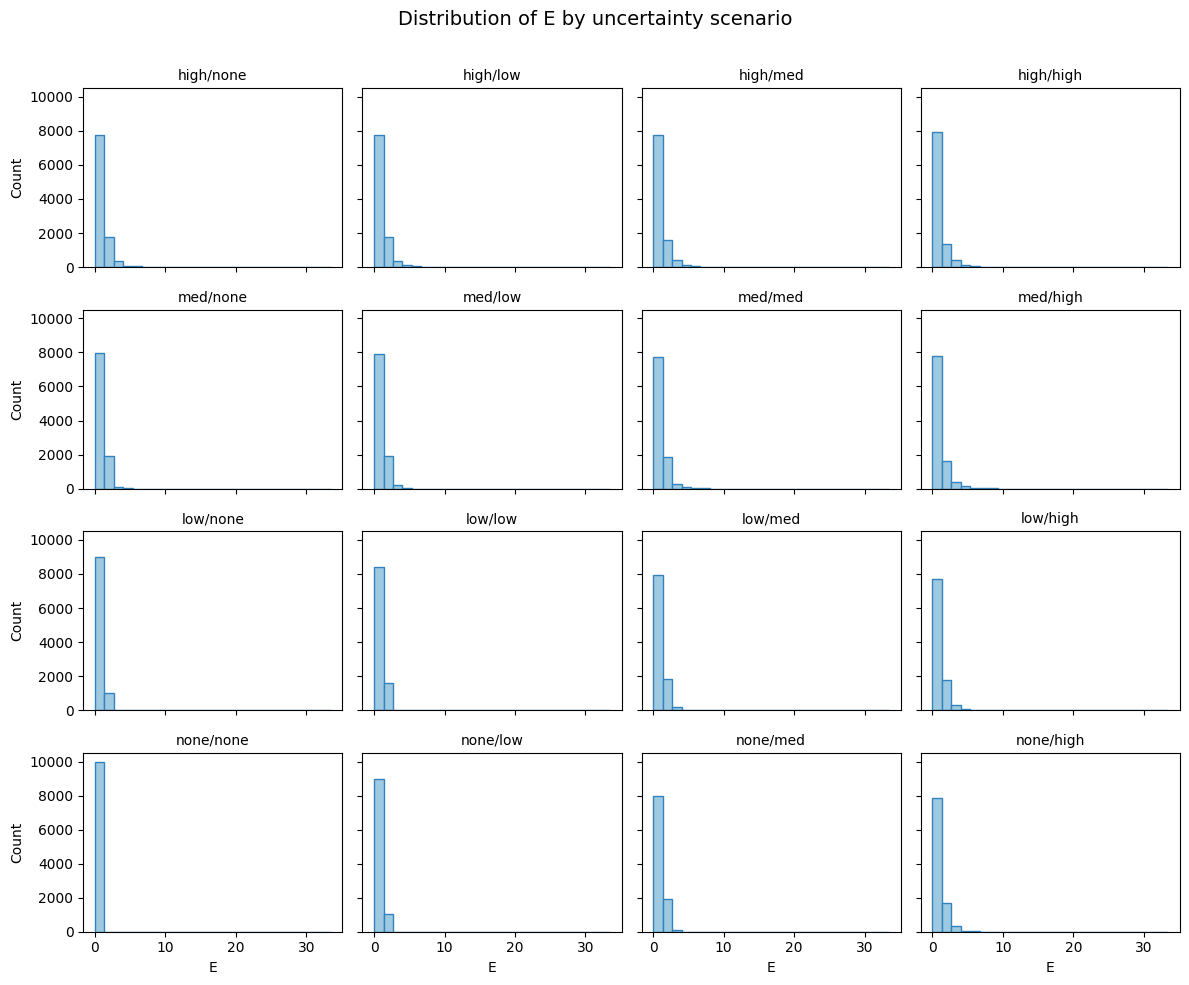

In [23]:
all_E_values = []
for row in estimate_samples_matrix:
    for samples in row:
        all_E_values.extend(samples)

global_max_E = max(all_E_values)

fig, axes = plt.subplots(len(levels), len(levels), figsize=(12, 10), sharex=True, sharey=True)

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        plot_row = len(levels) - 1 - row_index
        ax = axes[plot_row][col_index]
        E_values = estimate_samples_matrix[row_index][col_index]

        ax.hist(
            E_values,
            bins=25,
            range=(0.0, global_max_E),
            color="#9ecae1",
            edgecolor="#3182bd",
        )
        ax.set_title(f"{levels[row_index]}/{levels[col_index]}", fontsize=11, color="black")

        if plot_row == len(levels) - 1:
            ax.set_xlabel("E", fontsize=11, color="black")
        if col_index == 0:
            ax.set_ylabel("Count", fontsize=11, color="black")
        ax.tick_params(axis="both", labelsize=10, colors="black")

fig.suptitle("Distribution of E by uncertainty scenario", fontsize=16, color="black")
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("Figures/estimate_histogram_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Cost Breakdown Matrix Plot

This plot colors each scenario by expected total cost and also shows the expected investment cost and estimate-based shortfall cost, both as values and as shares of the total.

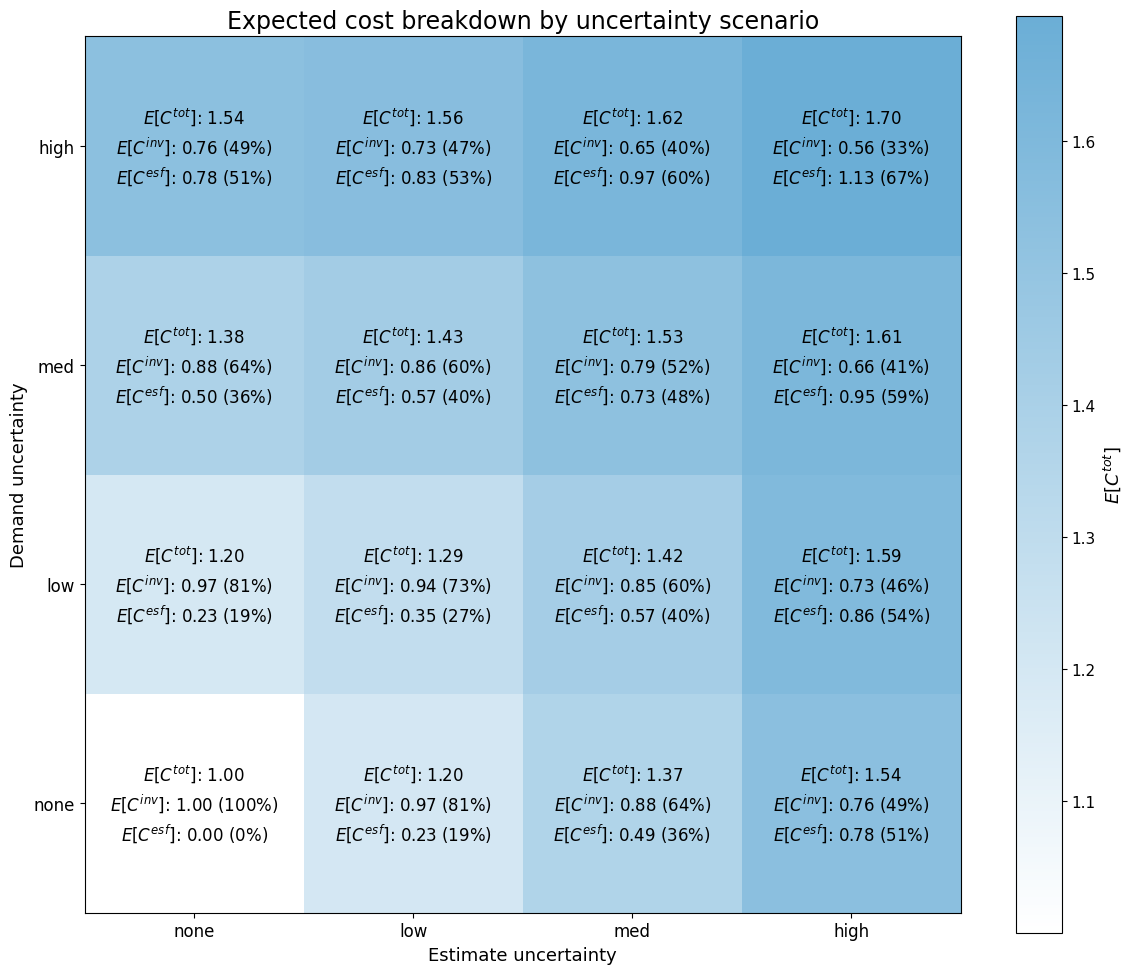

In [22]:
total_cost_plot = [[0.0 for _ in levels] for _ in levels]
investment_cost_plot = [[0.0 for _ in levels] for _ in levels]
shortfall_cost_plot = [[0.0 for _ in levels] for _ in levels]

for _, row in scenario_table.iterrows():
    row_index = levels.index(row["demand_level"])
    col_index = levels.index(row["estimate_level"])
    total_cost_plot[row_index][col_index] = row["expected_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    shortfall_cost_plot[row_index][col_index] = row["expected_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Expected cost breakdown by uncertainty scenario", fontsize=17, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        total_value = total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        shortfall_value = shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        shortfall_share = 100 * shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{esf}}]$: {shortfall_value:.2f} ({shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=13, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_cost_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()

## Demand Shortfall Cost Breakdown Matrix Plot

This plot has the same style, but it uses the real demand shortfall cost
$E[C^{dsf}] = c^s (D - S)^+$
instead of the estimate-based shortfall cost.

In [ ]:
demand_total_cost_plot = [[0.0 for _ in levels] for _ in levels]
investment_cost_plot = [[0.0 for _ in levels] for _ in levels]
demand_shortfall_cost_plot = [[0.0 for _ in levels] for _ in levels]

for _, row in scenario_table.iterrows():
    row_index = levels.index(row["demand_level"])
    col_index = levels.index(row["estimate_level"])
    demand_total_cost_plot[row_index][col_index] = row["expected_demand_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    demand_shortfall_cost_plot[row_index][col_index] = row["expected_demand_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(demand_total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Demand-shortfall cost breakdown by uncertainty scenario", fontsize=17, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        total_value = demand_total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        demand_shortfall_value = demand_shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        demand_shortfall_share = 100 * demand_shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{dsf}}]$: {demand_shortfall_value:.2f} ({demand_shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=13, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_demand_shortfall_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()